# Detecção de Spam em Mensagens SMS — Projeto Avaliativo P2

**Curso:** A.I - Classificadores · **Universidade de Marília (UNIMAR)** · 2026/1
**Grupo:** 5 · **Domínio:** NLP / Segurança
**Tipo de problema:** Classificação binária supervisionada (dataset desbalanceado)
**Dataset:** [UCI SMS Spam Collection (Kaggle)](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

---

### O que mudou da P1 para a P2 (evolução solicitada na devolutiva)

Esta versão é uma evolução real da entregue na P1. As melhorias estão sinalizadas ao longo do
notebook com o selo **`★ MELHORIA P2`** e estão resumidas abaixo:

| # | Melhoria | Por que melhora o projeto |
|---|----------|---------------------------|
| 1 | **Remoção de mensagens duplicadas** | O dataset tem 403 duplicatas exatas. Se não forem removidas, a mesma mensagem pode cair no treino e no teste ao mesmo tempo (*data leakage*), inflando artificialmente as métricas. |
| 2 | **Uso de `Pipeline` (TF-IDF + classificador)** | Garante que o TF-IDF seja ajustado **apenas** com os dados de treino dentro de cada *fold* da validação cruzada. Na P1 o TF-IDF era ajustado no conjunto inteiro antes da CV, o que vazava vocabulário das partições de validação e gerava métricas otimistas. |
| 3 | **Otimização de hiperparâmetros com `GridSearchCV`** | Em vez de escolher `alpha`, `C` e `max_features` na mão, fazemos uma busca sistemática validada por F1. |
| 4 | **Curvas Precision-Recall + AUC-PR** | Em problemas desbalanceados a curva PR é mais informativa que a ROC, pois foca na classe minoritária (spam). |
| 5 | **Análise de limiar (threshold)** | Mostramos o trade-off precisão × recall ao variar o ponto de corte, em vez de assumir 0,5 cego. |
| 6 | **Modelo final salvo com `joblib`** | O `Pipeline` final (vetorizador + modelo) é serializado e recarregado, pronto para a aplicação Streamlit. |
| 7 | **Modelo final treinado em todos os dados** | Após a comparação, o modelo escolhido é re-treinado com treino+validação+teste para entregar ao app a melhor versão possível. |


## 0. Bibliotecas importadas

Cada biblioteca tem uma função clara no projeto:

- **`re`** — expressões regulares, usadas na limpeza do texto.
- **`numpy` / `pandas`** — manipulação numérica e de tabelas (o dataset é um `DataFrame`).
- **`matplotlib` / `seaborn`** — geração dos gráficos da análise.
- **`wordcloud`** — nuvens de palavras por classe.
- **`sklearn.feature_extraction.text.TfidfVectorizer`** — transforma texto em vetores numéricos TF-IDF.
- **`sklearn.pipeline.Pipeline`** — encadeia vetorizador + classificador em um único objeto.
- **`sklearn.model_selection`** — `train_test_split` (divisão dos dados), `StratifiedKFold` (validação cruzada estratificada), `GridSearchCV` (busca de hiperparâmetros), `cross_validate` (avaliação por CV).
- **`MultinomialNB`, `LogisticRegression`, `LinearSVC`** — os três classificadores comparados.
- **`CalibratedClassifierCV`** — embrulha o `LinearSVC` para que ele consiga gerar probabilidades (`predict_proba`), necessárias para as curvas ROC/PR.
- **`sklearn.metrics`** — todas as métricas de avaliação.
- **`joblib`** — salva e carrega o modelo final.

In [1]:
# ── Padrão ────────────────────────────────────────────────────────────────────
import re
import warnings
warnings.filterwarnings('ignore')

# ── Dados ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

# ── NLP / vetorização ─────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# ── Seleção de modelo ─────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)

# ── Classificadores ───────────────────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Persistência do modelo ────────────────────────────────────────────────────
import joblib

# ── Reprodutibilidade: fixa a semente para que os resultados sejam sempre iguais
SEED = 42
np.random.seed(SEED)

# ── Estilo dos gráficos ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
BLUE, RED, GREEN = '#4c9be8', '#e85c4c', '#27ae60'

print('Ambiente pronto.')

Ambiente pronto.


---
## Etapa 1 — Análise Exploratória (EDA)

### 1.1 Carregamento dos dados

O arquivo do Kaggle (`spam.csv`) vem em codificação **latin-1** e possui 5 colunas, mas só duas
são úteis: `v1` (rótulo: *ham* ou *spam*) e `v2` (texto da mensagem). As outras três colunas estão
quase totalmente vazias e são descartadas.

A célula tenta ler o arquivo local; se ele não existir, baixa de um espelho público (deixa o
notebook executável de ponta a ponta para a avaliação).

In [2]:
# Tenta ler localmente; se não houver, baixa de um espelho público do mesmo dataset
import os, urllib.request
CSV_PATH = 'spam.csv'
if not os.path.exists(CSV_PATH):
    url = ('https://raw.githubusercontent.com/mohitgupta-omg/'
           'Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv')
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset baixado do espelho público.')

# read_csv: função do pandas para ler arquivos CSV
#   encoding='latin-1' -> codificação correta deste arquivo
df = pd.read_csv(CSV_PATH, encoding='latin-1')

# Mantém só as duas colunas úteis e renomeia para nomes claros
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

print('Formato (linhas, colunas):', df.shape)
df.head()

Formato (linhas, colunas): (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 1.2 Inspeção inicial

- **`.info()`** mostra tipos das colunas e quantos valores não-nulos existem.
- **`.isnull().sum()`** confirma se há valores ausentes.
- **`.value_counts()`** conta quantas mensagens há de cada classe.

In [3]:
print('--- Estrutura (.info) ---')
df.info()

print('\n--- Valores ausentes (.isnull) ---')
print(df.isnull().sum())

print('\n--- Contagem por classe (.value_counts) ---')
print(df['label'].value_counts())

--- Estrutura (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB

--- Valores ausentes (.isnull) ---
label    0
text     0
dtype: int64

--- Contagem por classe (.value_counts) ---
label
ham     4825
spam     747
Name: count, dtype: int64


### 1.3 ★ MELHORIA P2 — Tratamento de duplicatas

O SMS Spam Collection contém **mensagens repetidas**. Mantê-las causa dois problemas:

1. **Data leakage:** a mesma mensagem pode aparecer no treino e no teste, fazendo o modelo "decorar"
   em vez de generalizar — as métricas ficam otimistas demais.
2. **Viés na contagem:** classes ficam com peso artificial.

`.duplicated()` marca as linhas repetidas; `.drop_duplicates()` as remove.

In [4]:
n_antes = len(df)
n_dups = df.duplicated().sum()          # quantas linhas são repetições exatas
print(f'Linhas duplicadas encontradas: {n_dups}')

df = df.drop_duplicates().reset_index(drop=True)   # remove e reindexa
print(f'Linhas antes: {n_antes}  ->  depois: {len(df)}')
print('\nNova distribuição de classes:')
print(df['label'].value_counts())
print(f"\nProporção de spam: {df['label'].eq('spam').mean()*100:.2f}%")

Linhas duplicadas encontradas: 403
Linhas antes: 5572  ->  depois: 5169

Nova distribuição de classes:
label
ham     4516
spam     653
Name: count, dtype: int64

Proporção de spam: 12.63%


### 1.4 Distribuição das classes

Visualizamos a proporção ham × spam. O gráfico evidencia o **desbalanceamento**: spam é a classe
minoritária (~13%). Isso justifica usar **F1-Score** e **AUC-PR** como métricas principais, e não só
a acurácia (que seria enganosa — um modelo que chutasse "tudo ham" já acertaria ~87%).

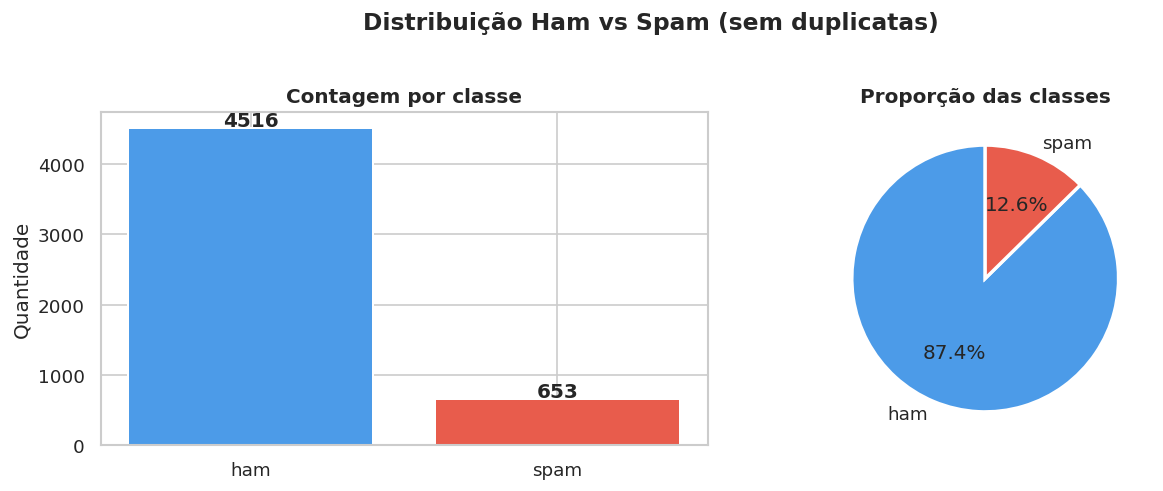

Dataset desbalanceado: spam e a classe minoritaria (~13%).


In [5]:
vc = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(vc.index, vc.values, color=[BLUE, RED], edgecolor='white', linewidth=1.2)
for i, (c, v) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Contagem por classe', fontweight='bold')
axes[0].set_ylabel('Quantidade')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=[BLUE, RED],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção das classes', fontweight='bold')

plt.suptitle('Distribuição Ham vs Spam (sem duplicatas)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Dataset desbalanceado: spam e a classe minoritaria (~13%).')

### 1.5 Tamanho das mensagens por classe

Criamos duas variáveis derivadas — `num_chars` (nº de caracteres) e `num_words` (nº de palavras) —
e comparamos as distribuições. **Mensagens de spam tendem a ser mais longas** (ofertas, links,
instruções), o que já é um sinal discriminante.

Médias por classe:
       num_chars  num_words
label                      
ham         70.5       14.1
spam       137.9       23.7


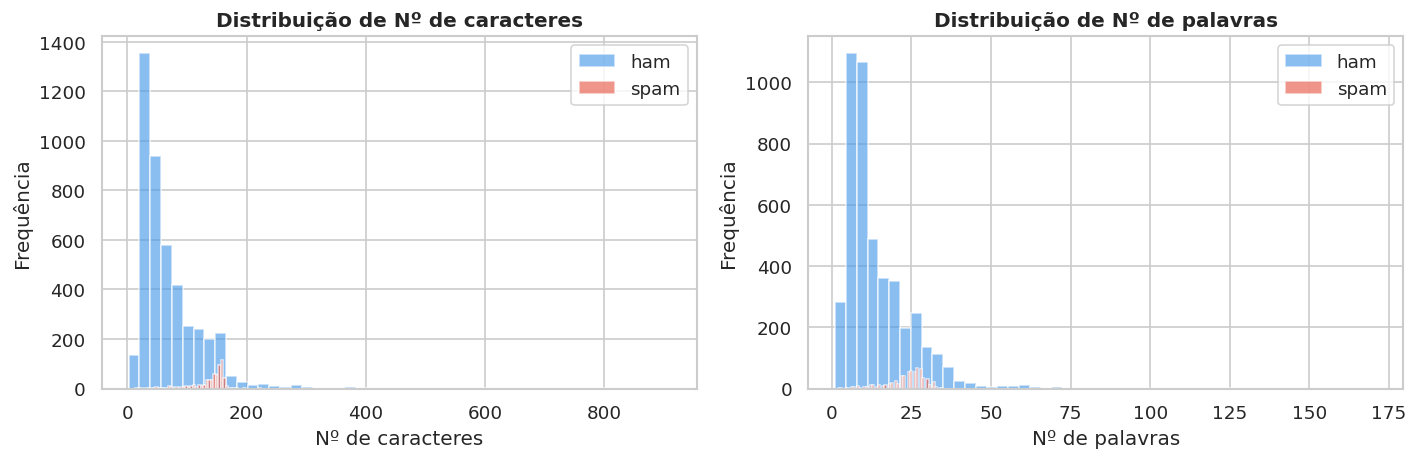

In [6]:
df['num_chars'] = df['text'].str.len()              # comprimento em caracteres
df['num_words'] = df['text'].str.split().str.len()  # nº de palavras (split por espaço)

print('Médias por classe:')
print(df.groupby('label')[['num_chars', 'num_words']].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, titulo in zip(axes, ['num_chars', 'num_words'], ['Nº de caracteres', 'Nº de palavras']):
    for lab, cor in zip(['ham', 'spam'], [BLUE, RED]):
        ax.hist(df.loc[df['label'] == lab, col], bins=50, alpha=0.65,
                color=cor, label=lab, edgecolor='white')
    ax.set_title(f'Distribuição de {titulo}', fontweight='bold')
    ax.set_xlabel(titulo); ax.set_ylabel('Frequência'); ax.legend()
plt.tight_layout()
plt.show()

### 1.6 Nuvens de palavras (word clouds)

As nuvens mostram, visualmente, as palavras mais frequentes em cada classe (quanto maior, mais
frequente). Em **spam** aparecem termos comerciais/golpe (*free, call, txt, claim, win, prize*); em
**ham**, vocabulário cotidiano (*ok, home, later, got*). Stopwords (palavras vazias como *the, to, you*)
são removidas para não poluir.

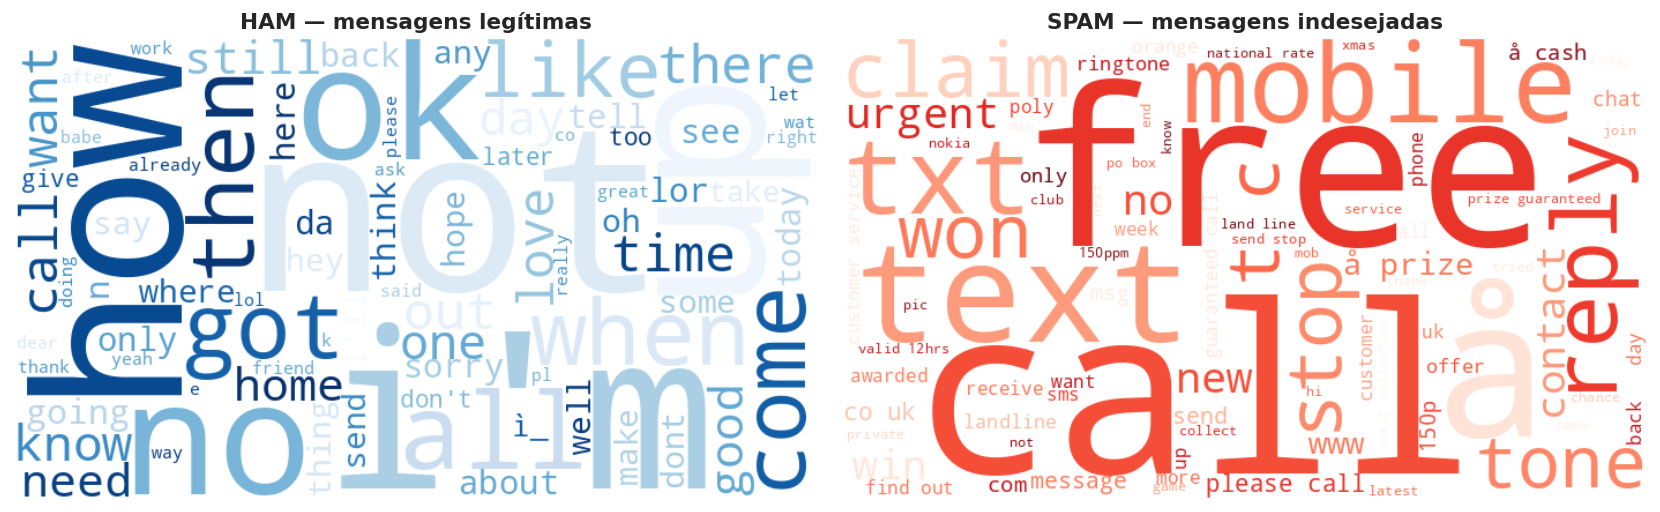

In [7]:
stopwords_en = {
    'i','me','my','we','our','you','your','he','him','his','she','her','it','its','they',
    'them','their','what','which','who','this','that','these','those','am','is','are','was',
    'were','be','been','being','have','has','had','do','does','did','will','would','should',
    'can','could','may','to','of','in','for','on','with','as','by','from','at','an','a','the',
    'and','but','or','so','if','u','ur','r','gt','lt','now','just','get','go'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lab, cmap, titulo in zip(
        axes, ['ham', 'spam'], ['Blues', 'Reds'],
        ['HAM — mensagens legítimas', 'SPAM — mensagens indesejadas']):
    corpus = ' '.join(df.loc[df['label'] == lab, 'text'].str.lower())
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, stopwords=stopwords_en, max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(titulo, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Etapa 2 — Pré-processamento

### 2.1 Limpeza de texto

A função `clean_text` padroniza cada mensagem em três passos:
1. **`lower()`** — tudo em minúsculas (para "FREE" e "free" serem a mesma palavra).
2. **`re.sub(r'[^a-z\s]', ' ', t)`** — remove pontuação e números, deixando só letras e espaços.
3. **`re.sub(r'\s+', ' ', t)`** — colapsa espaços múltiplos em um só.

O resultado vai para a coluna `text_clean`.

In [8]:
def clean_text(t: str) -> str:
    """Coloca em minúsculas, remove pontuação/números e normaliza espaços."""
    t = t.lower()
    t = re.sub(r'[^a-z\s]', ' ', t)   # mantém apenas letras a-z e espaços
    t = re.sub(r'\s+', ' ', t).strip()  # colapsa espaços repetidos
    return t

df['text_clean'] = df['text'].apply(clean_text)

print('Original:', df['text'].iloc[2])
print('Limpa   :', df['text_clean'].iloc[2])

Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Limpa   : free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s


### 2.2 Variável-alvo e variáveis de entrada

- **Variável de entrada (X):** `text_clean` — o texto limpo.
- **Variável-alvo (y):** `label_enc` — o rótulo codificado em número.

Para classificação binária, codificamos **ham = 0** e **spam = 1**. Aqui usamos uma comparação
booleana (`== 'spam'`) convertida em inteiro, que é equivalente ao `LabelEncoder` mas deixa explícito
qual classe é a positiva (spam = 1, que é o que queremos detectar).

In [9]:
df['label_enc'] = (df['label'] == 'spam').astype(int)   # ham=0, spam=1
print('Mapeamento -> ham:0, spam:1')
print(df[['label', 'label_enc']].drop_duplicates().to_string(index=False))

X = df['text_clean']   # entrada
y = df['label_enc']    # alvo

Mapeamento -> ham:0, spam:1
label  label_enc
  ham          0
 spam          1


### 2.3 Divisão treino / validação / teste (estratificada)

Dividimos em **70% treino · 15% validação · 15% teste**, em duas etapas com `train_test_split`.
Parâmetros importantes:
- **`test_size`** — fração separada para fora do treino.
- **`stratify=y`** — mantém a **mesma proporção de spam** em todas as partições (essencial em dados
  desbalanceados; sem isso, um conjunto poderia ficar quase sem spam).
- **`random_state=SEED`** — torna a divisão reprodutível.

In [10]:
# 1ª divisão: 70% treino, 30% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

# 2ª divisão: parte o temporário ao meio -> 15% validação, 15% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

for nome, ys in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    print(f'{nome:>10}: {len(ys):>4} amostras | spam {ys.mean()*100:5.2f}%')

    Treino: 3618 amostras | spam 12.63%
 Validação:  775 amostras | spam 12.65%
     Teste:  776 amostras | spam 12.63%


### 2.4 Extração de features — TF-IDF

O **TF-IDF** (*Term Frequency – Inverse Document Frequency*) converte cada mensagem em um vetor
numérico: dá peso alto a palavras frequentes na mensagem mas raras no conjunto (logo, mais
informativas), e peso baixo a palavras comuns em tudo.

Parâmetros usados:
- **`ngram_range=(1, 2)`** — considera palavras isoladas (unigramas) **e** pares de palavras
  (bigramas), capturando expressões como *"free entry"* ou *"call now"*.
- **`sublinear_tf=True`** — aplica `1 + log(tf)`, suavizando palavras muito repetidas.
- **`stop_words='english'`** — ignora palavras vazias em inglês.
- **`max_features`** — limita o tamanho do vocabulário (definido pela busca da Etapa 3).

> **★ MELHORIA P2:** na P1 o TF-IDF era ajustado fora da validação cruzada. Aqui ele entra **dentro
> de um `Pipeline`** (próxima etapa), de modo que o `.fit` use só os dados de treino de cada *fold* —
> eliminando o vazamento de vocabulário e tornando as métricas honestas.

In [11]:
# Demonstração isolada do TF-IDF (a versão usada de fato fica dentro do Pipeline)
demo_tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                             stop_words='english', max_features=10000)
demo_matriz = demo_tfidf.fit_transform(X_train)
print('Matriz de treino (mensagens x features):', demo_matriz.shape)
print('Exemplos de tokens do vocabulário:',
      list(demo_tfidf.get_feature_names_out()[1000:1008]))

Matriz de treino (mensagens x features): (3618, 10000)
Exemplos de tokens do vocabulário: ['contented', 'contented sigh', 'contention', 'contention grow', 'contents', 'contents page', 'continent', 'continue']


---
## Etapa 3 — Comparação de Classificadores

### 3.1 ★ MELHORIA P2 — Pipelines (TF-IDF + classificador)

Cada classificador é embrulhado em um `Pipeline` com duas etapas nomeadas: `tfidf` e `clf`. Vantagens:
- O vetorizador é **re-ajustado dentro de cada fold** da validação cruzada → sem vazamento.
- O objeto final é **um só** (texto entra cru, predição sai), o que simplifica o salvamento e o app.

Os três classificadores (sugeridos no enunciado):
- **`MultinomialNB`** — Naive Bayes multinomial, baseline clássico e forte para texto/spam.
- **`LogisticRegression`** — modelo linear probabilístico; `class_weight='balanced'` compensa o
  desbalanceamento dando mais peso à classe minoritária.
- **`LinearSVC`** — SVM linear, ótimo para texto esparso; envolto em `CalibratedClassifierCV` para
  produzir probabilidades (o `LinearSVC` puro não tem `predict_proba`).

In [12]:
def make_pipe(classificador):
    """Cria um Pipeline: TF-IDF -> classificador."""
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                                  stop_words='english')),
        ('clf', classificador),
    ])

modelos = {
    'MultinomialNB': make_pipe(MultinomialNB()),
    'LogisticRegression': make_pipe(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)),
    'LinearSVC': make_pipe(
        CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', max_iter=5000, random_state=SEED))),
}
print('Pipelines criados:', list(modelos.keys()))

Pipelines criados: ['MultinomialNB', 'LogisticRegression', 'LinearSVC']


### 3.2 ★ MELHORIA P2 — Otimização de hiperparâmetros (`GridSearchCV`)

Em vez de chutar os hiperparâmetros, o `GridSearchCV` testa **todas as combinações** de uma grade e
escolhe a melhor por **validação cruzada estratificada (k=5)**, otimizando o **F1** (métrica adequada
ao desbalanceamento).

- **`StratifiedKFold(n_splits=5, shuffle=True)`** — 5 partições mantendo a proporção de classes.
- **`scoring='f1'`** — critério de seleção.
- **`n_jobs=-1`** — usa todos os núcleos da CPU (mais rápido).

Esta célula pode levar ~1–2 min.

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Grades de busca por modelo (parâmetros prefixados pelo nome da etapa do Pipeline)
grades = {
    'MultinomialNB':      {'tfidf__max_features': [5000, 10000],
                           'clf__alpha': [0.05, 0.1, 0.5, 1.0]},
    'LogisticRegression': {'tfidf__max_features': [5000, 10000],
                           'clf__C': [0.5, 1.0, 5.0, 10.0]},
    'LinearSVC':          {'tfidf__max_features': [5000, 10000],
                           'clf__estimator__C': [0.5, 1.0, 5.0]},
}

modelos_tunados = {}
for nome, pipe in modelos.items():
    busca = GridSearchCV(pipe, grades[nome], scoring='f1', cv=skf, n_jobs=-1)
    busca.fit(X_train, y_train)
    modelos_tunados[nome] = busca.best_estimator_
    print(f'{nome:>20} | melhor F1 (CV): {busca.best_score_:.4f} | {busca.best_params_}')

       MultinomialNB | melhor F1 (CV): 0.9305 | {'clf__alpha': 0.05, 'tfidf__max_features': 10000}


  LogisticRegression | melhor F1 (CV): 0.9268 | {'clf__C': 10.0, 'tfidf__max_features': 10000}


           LinearSVC | melhor F1 (CV): 0.9241 | {'clf__estimator__C': 5.0, 'tfidf__max_features': 10000}


### 3.3 Validação cruzada do melhor estimador (k=5)

Com os modelos já tunados, rodamos `cross_validate` para obter as **cinco métricas** médias na
validação cruzada. Como tudo está dentro do `Pipeline`, **não há vazamento**: em cada *fold* o TF-IDF
é ajustado só na parte de treino daquele *fold*.

In [14]:
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados_cv = {}
for nome, est in modelos_tunados.items():
    sc = cross_validate(est, X_train, y_train, cv=skf, scoring=metricas_cv, n_jobs=-1)
    resultados_cv[nome] = {m.replace('test_', ''): sc[m].mean()
                           for m in sc if m.startswith('test_')}

cv_df = pd.DataFrame(resultados_cv).T
cv_df.columns = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
print('=== Validação cruzada (k=5) no conjunto de treino ===')
cv_df.round(4)

=== Validação cruzada (k=5) no conjunto de treino ===


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
MultinomialNB,0.9831,0.9654,0.8993,0.9305,0.9874
LogisticRegression,0.9818,0.9382,0.9169,0.9268,0.9882
LinearSVC,0.9809,0.9281,0.9212,0.9241,0.9892


### 3.4 Avaliação no conjunto de teste

Agora treinamos cada modelo em todo o treino e avaliamos no **teste** (dados nunca vistos). Para cada
modelo guardamos predições (`.predict`) e probabilidades (`.predict_proba`, coluna da classe spam)
para calcular todas as métricas, inclusive **AUC-ROC** e **AUC-PR**.

In [15]:
resultados_teste = {}
preds = {}
for nome, est in modelos_tunados.items():
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    y_prob = est.predict_proba(X_test)[:, 1]    # probabilidade de ser spam
    preds[nome] = (y_pred, y_prob)
    resultados_teste[nome] = {
        'Acurácia':  accuracy_score(y_test, y_pred),
        'Precisão':  precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
        'AUC-PR':    average_precision_score(y_test, y_prob),
    }

teste_df = pd.DataFrame(resultados_teste).T
print('=== Resultados no conjunto de teste ===')
teste_df.round(4)

=== Resultados no conjunto de teste ===


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,AUC-PR
MultinomialNB,0.9871,0.9681,0.9286,0.9479,0.9943,0.9780
LogisticRegression,0.9858,0.9780,0.9082,0.9418,0.9897,0.9699
LinearSVC,0.9871,0.9783,0.9184,0.9474,0.9853,0.9643


### 3.5 Matrizes de confusão

A matriz de confusão mostra acertos e erros por classe:
- **Verdadeiro Negativo (TN):** ham corretamente identificado.
- **Falso Positivo (FP):** ham marcado como spam → mensagem legítima vai para o lixo (incômodo).
- **Falso Negativo (FN):** spam que passou como ham → golpe/propaganda chega ao usuário (mais grave).
- **Verdadeiro Positivo (TP):** spam corretamente bloqueado.

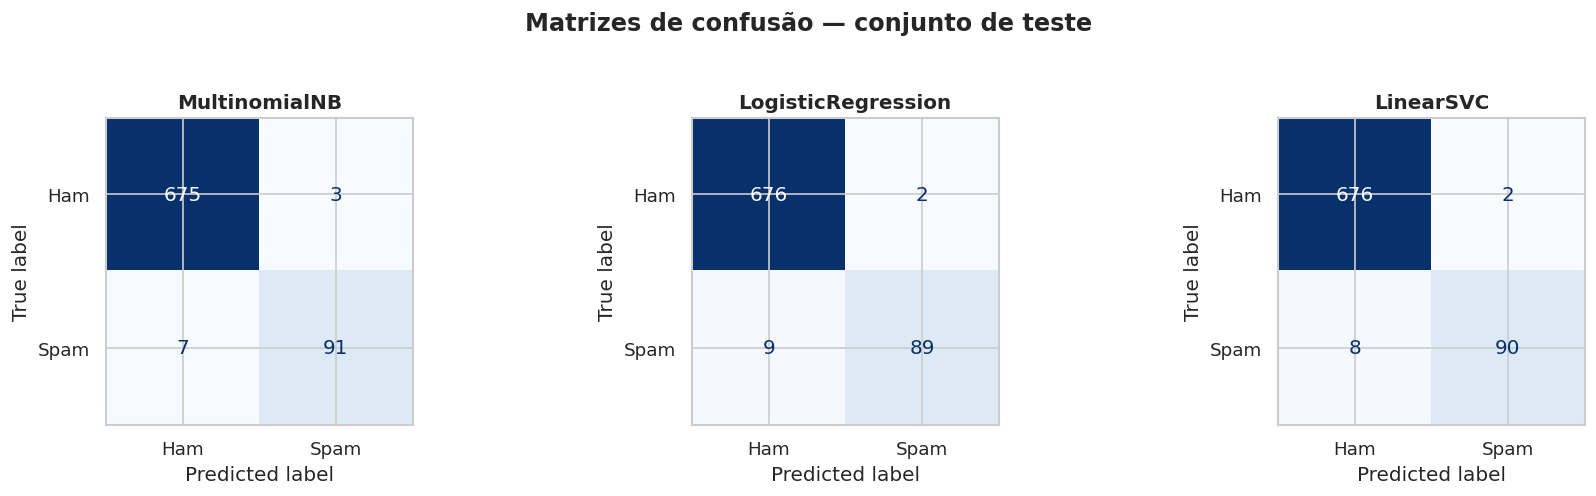

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nome in zip(axes, modelos_tunados):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds[nome][0], display_labels=['Ham', 'Spam'],
        colorbar=False, cmap='Blues', ax=ax)
    ax.set_title(nome, fontweight='bold')
plt.suptitle('Matrizes de confusão — conjunto de teste', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 3.6 Curvas ROC e ★ Precision-Recall (AUC-PR)

- **ROC** relaciona taxa de verdadeiros positivos × falsos positivos; **AUC-ROC** resume isso (1,0 = perfeito).
- **★ MELHORIA P2 — Precision-Recall:** em dados desbalanceados a curva PR é **mais informativa**,
  pois ignora os verdadeiros negativos (ham, classe majoritária) e foca no desempenho sobre spam. A
  área sob ela é a **AUC-PR** (*Average Precision*).

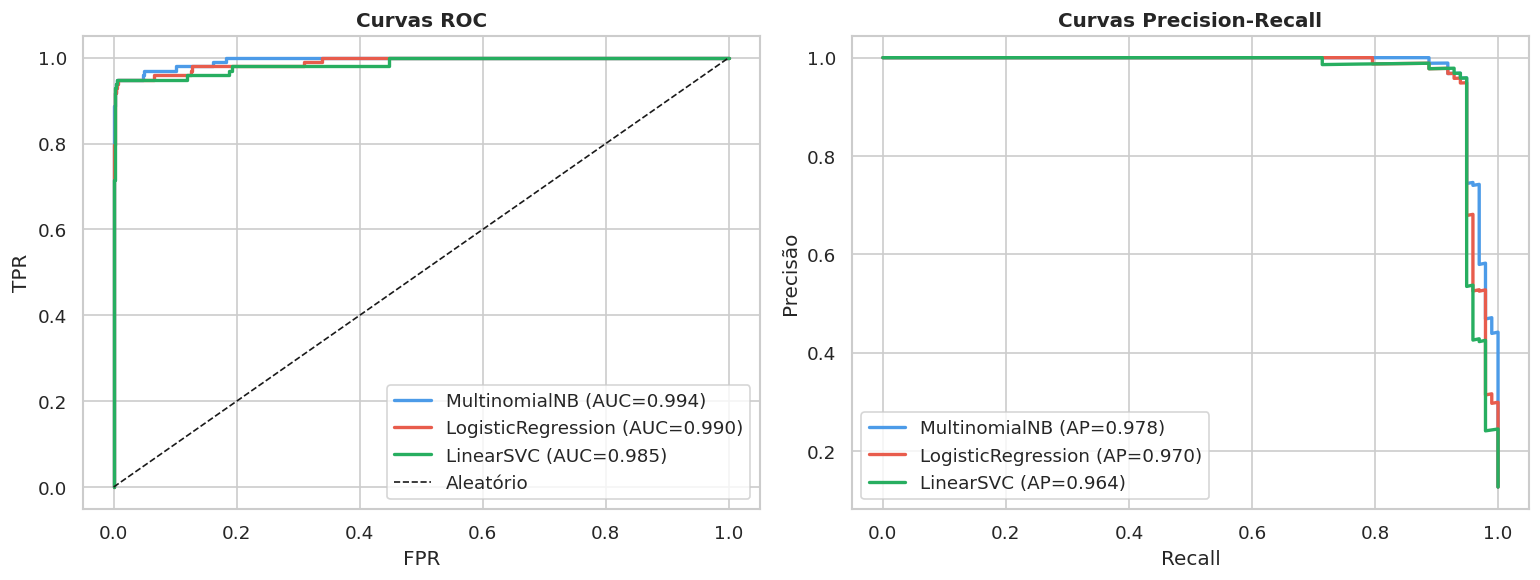

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nome, cor in zip(modelos_tunados, [BLUE, RED, GREEN]):
    y_prob = preds[nome][1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=cor, lw=2,
                 label=f'{nome} (AUC={roc_auc_score(y_test, y_prob):.3f})')
    p, r, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(r, p, color=cor, lw=2,
                 label=f'{nome} (AP={average_precision_score(y_test, y_prob):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC', fontweight='bold'); axes[0].legend(loc='lower right')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisão')
axes[1].set_title('Curvas Precision-Recall', fontweight='bold'); axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

---
## Etapa 4 — Análise Comparativa

### 4.1 Comparativo visual das métricas

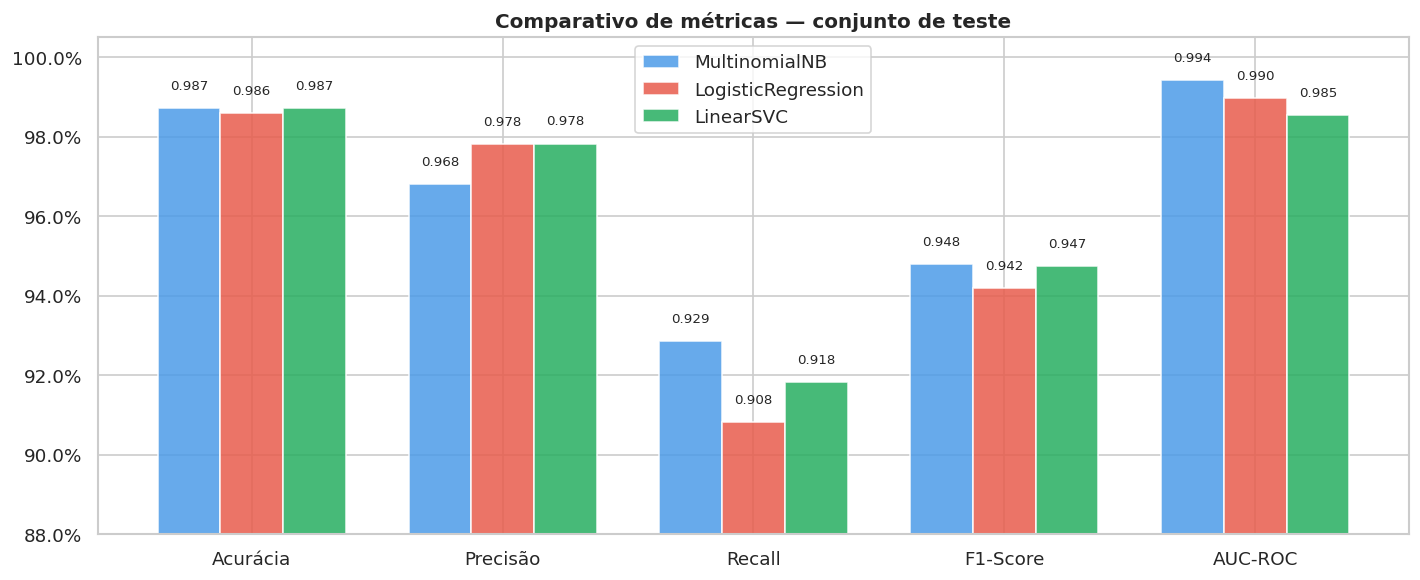

In [18]:
mets = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(mets)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (nome, cor) in enumerate(zip(modelos_tunados, [BLUE, RED, GREEN])):
    vals = [resultados_teste[nome][m] for m in mets]
    barras = ax.bar(x + i*w, vals, w, label=nome, color=cor, alpha=0.85)
    for b, v in zip(barras, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + w); ax.set_xticklabels(mets); ax.set_ylim(0.88, 1.005)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Comparativo de métricas — conjunto de teste', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Qual classificador teve melhor desempenho?

Escolhemos o melhor pela **F1-Score** (equilíbrio entre precisão e recall, a métrica certa para dados
desbalanceados). O `classification_report` detalha precisão/recall/F1 por classe.

In [19]:
melhor_nome = teste_df['F1-Score'].idxmax()
print(f'>>> Melhor modelo por F1-Score: {melhor_nome}\n')
print(classification_report(y_test, preds[melhor_nome][0],
                            target_names=['Ham', 'Spam']))

>>> Melhor modelo por F1-Score: MultinomialNB

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       678
        Spam       0.97      0.93      0.95        98

    accuracy                           0.99       776
   macro avg       0.98      0.96      0.97       776
weighted avg       0.99      0.99      0.99       776



### 4.3 Análise de erros

Recuperamos os textos originais classificados errado pelo melhor modelo:
- **Falsos negativos** — spam que escapou (em geral mensagens sem as palavras-gatilho típicas).
- **Falsos positivos** — ham bloqueado por engano (costuma conter palavras que também aparecem em spam,
  como *free* ou *win*).

In [20]:
X_test_orig = df.loc[X_test.index, 'text']   # textos originais (não limpos) do teste
erros = pd.DataFrame({
    'texto':   X_test_orig.values,
    'real':    pd.Series(y_test.values).map({0: 'ham', 1: 'spam'}),
    'predito': pd.Series(preds[melhor_nome][0]).map({0: 'ham', 1: 'spam'}),
})

fn = erros[(erros.real == 'spam') & (erros.predito == 'ham')]   # spam perdido
fp = erros[(erros.real == 'ham')  & (erros.predito == 'spam')]  # ham bloqueado
print(f'Falsos negativos (spam perdido): {len(fn)}')
print(f'Falsos positivos (ham bloqueado): {len(fp)}\n')

print('--- Exemplos de FALSO NEGATIVO (spam que passou) ---')
for t in fn['texto'].head(3):
    print('  •', t[:110])
print('\n--- Exemplos de FALSO POSITIVO (ham bloqueado) ---')
for t in fp['texto'].head(3):
    print('  •', t[:110])

Falsos negativos (spam perdido): 7
Falsos positivos (ham bloqueado): 3

--- Exemplos de FALSO NEGATIVO (spam que passou) ---
  • Money i have won wining number 946 wot do i do next
  • Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntwk chg å£1.50
  • You can donate å£2.50 to UNICEF's Asian Tsunami disaster support fund by texting DONATE to 864233. å£2.50 will

--- Exemplos de FALSO POSITIVO (ham bloqueado) ---
  • K do I need a login or anything
  • K:)eng rocking in ashes:)
  • How much would it cost to hire a hitman


### 4.4 Feature importance — palavras mais indicativas de spam

A **Regressão Logística** tem coeficientes diretamente interpretáveis: coeficiente positivo empurra
para **spam**, negativo para **ham**. Listamos as 20 palavras mais fortes de cada lado. Confirma a
intuição do enunciado: *free, win, prize, call, claim* são marcadores fortes de spam.

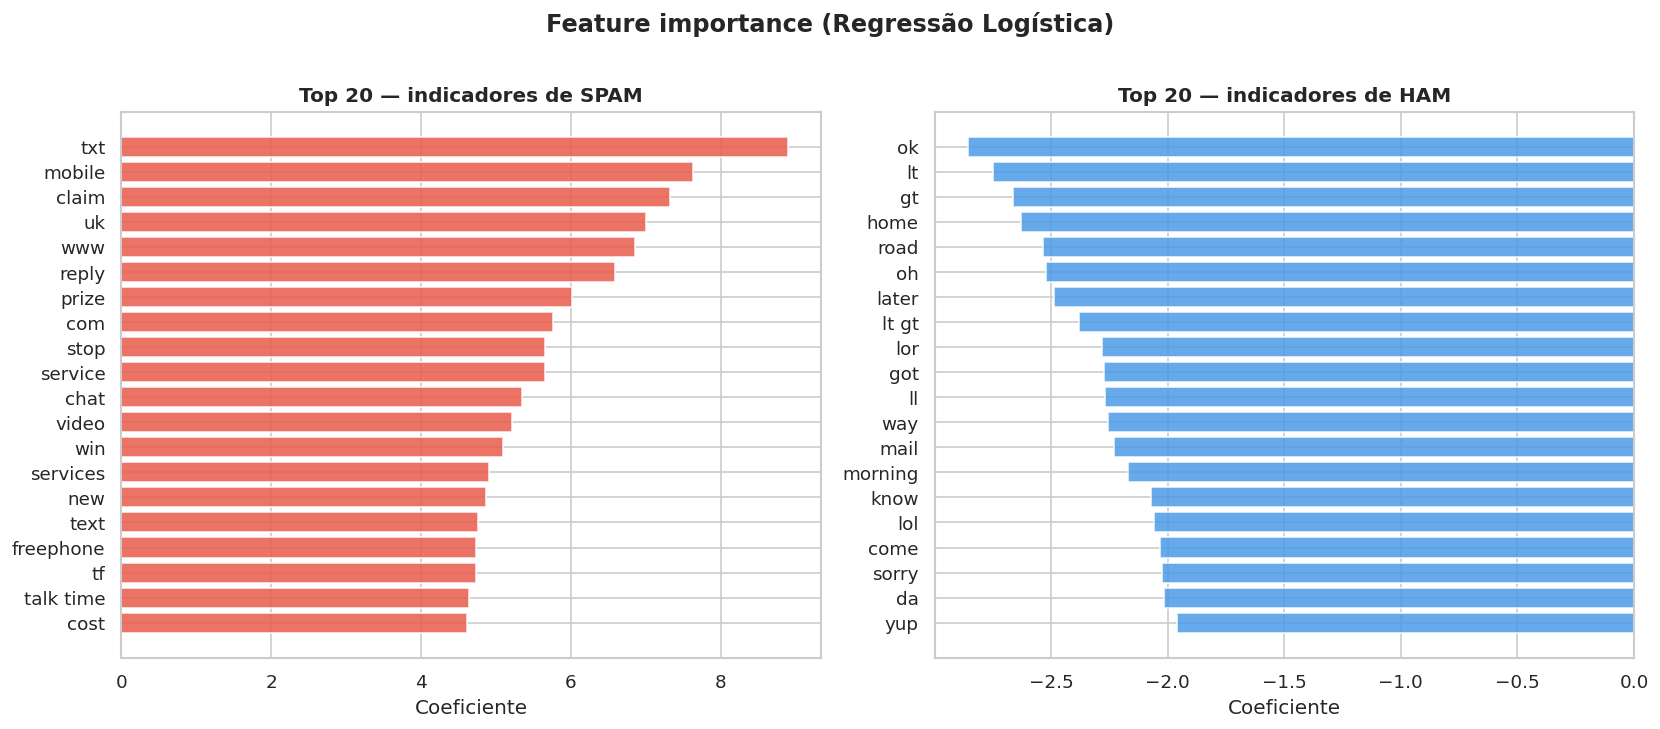

In [21]:
lr = modelos_tunados['LogisticRegression']
nomes_feat = np.array(lr.named_steps['tfidf'].get_feature_names_out())
coefs = lr.named_steps['clf'].coef_[0]

idx_spam = np.argsort(coefs)[::-1][:20]   # maiores coeficientes -> spam
idx_ham  = np.argsort(coefs)[:20]         # menores -> ham

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(nomes_feat[idx_spam][::-1], coefs[idx_spam][::-1], color=RED, alpha=0.85)
axes[0].set_title('Top 20 — indicadores de SPAM', fontweight='bold'); axes[0].set_xlabel('Coeficiente')
axes[1].barh(nomes_feat[idx_ham][::-1], coefs[idx_ham][::-1], color=BLUE, alpha=0.85)
axes[1].set_title('Top 20 — indicadores de HAM', fontweight='bold'); axes[1].set_xlabel('Coeficiente')
plt.suptitle('Feature importance (Regressão Logística)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.5 ★ MELHORIA P2 — Análise de limiar (threshold)

Por padrão classificamos como spam quando a probabilidade ≥ 0,5. Mas esse corte pode ser ajustado
conforme o objetivo: subir o limiar **aumenta a precisão** (menos ham bloqueado) ao custo de
**recall** (mais spam passa), e vice-versa. O gráfico mostra esse trade-off para o melhor modelo —
útil para justificar a escolha do ponto de operação em um cenário real.

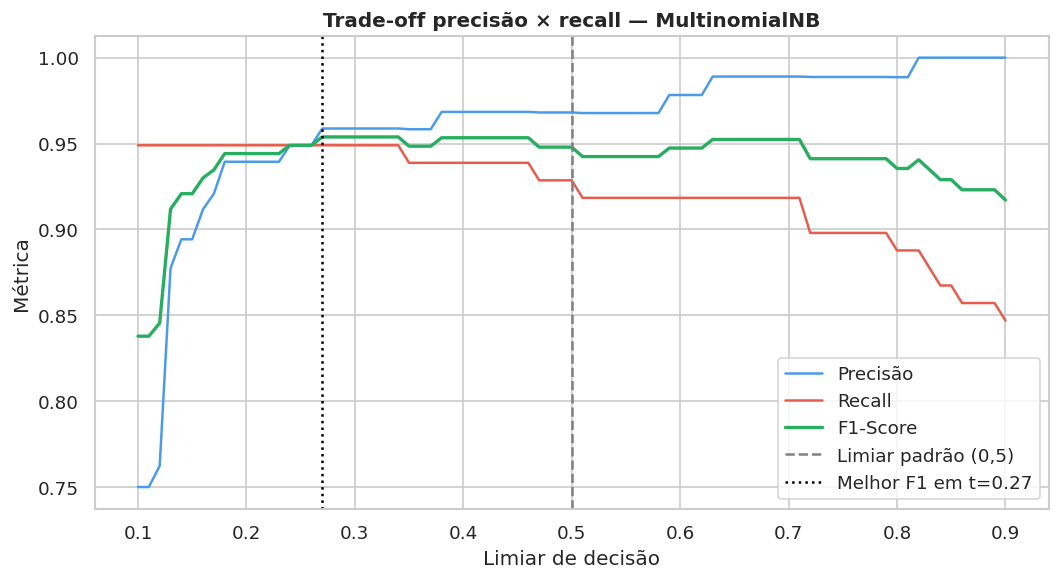

Limiar que maximiza F1: 0.27  (mantemos 0,5 como padrão do app)


In [22]:
y_prob_best = preds[melhor_nome][1]
limiares = np.linspace(0.1, 0.9, 81)
precs, recs, f1s = [], [], []
for t in limiares:
    yp = (y_prob_best >= t).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))

melhor_t = limiares[int(np.argmax(f1s))]
plt.figure(figsize=(9, 5))
plt.plot(limiares, precs, label='Precisão', color=BLUE)
plt.plot(limiares, recs, label='Recall', color=RED)
plt.plot(limiares, f1s, label='F1-Score', color=GREEN, lw=2)
plt.axvline(0.5, color='gray', ls='--', label='Limiar padrão (0,5)')
plt.axvline(melhor_t, color='black', ls=':', label=f'Melhor F1 em t={melhor_t:.2f}')
plt.xlabel('Limiar de decisão'); plt.ylabel('Métrica')
plt.title(f'Trade-off precisão × recall — {melhor_nome}', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.show()
print(f'Limiar que maximiza F1: {melhor_t:.2f}  (mantemos 0,5 como padrão do app)')

---
## Etapa 5 — ★ Modelo final salvo

### 5.1 Re-treino em todos os dados e serialização

Definido o melhor modelo, fazemos duas coisas:
1. **Re-treinamos em treino + validação + teste** — para a versão de produção, aproveitamos **todos**
   os exemplos rotulados (a avaliação honesta já foi feita acima, no teste).
2. **Salvamos com `joblib.dump`** — o `Pipeline` inteiro (TF-IDF + modelo) vira um único arquivo
   `.joblib`. Assim o app recebe texto cru e devolve a predição, sem precisar recriar o vetorizador.

In [23]:
# Modelo final = melhor pipeline re-treinado em TODOS os dados rotulados
modelo_final = modelos_tunados[melhor_nome]
X_full = pd.concat([X_train, X_val, X_test])
y_full = pd.concat([y_train, y_val, y_test])
modelo_final.fit(X_full, y_full)

# Serialização
joblib.dump(modelo_final, 'modelo_final.joblib')
print(f'Modelo final ({melhor_nome}) salvo em: modelo_final.joblib')

Modelo final (MultinomialNB) salvo em: modelo_final.joblib


### 5.2 Teste de carregamento (sanidade)

Recarregamos o arquivo com `joblib.load` e testamos com duas frases novas — exatamente o que o app
fará. Confirma que o modelo salvo está utilizável de ponta a ponta.

In [24]:
modelo_carregado = joblib.load('modelo_final.joblib')

exemplos = [
    'Congratulations! You won a FREE prize. Call now to claim your reward!!!',
    'Hey, are we still meeting for lunch tomorrow?',
]
for msg in exemplos:
    limpo = clean_text(msg)
    pred = modelo_carregado.predict([limpo])[0]
    prob = modelo_carregado.predict_proba([limpo])[0, 1]
    rotulo = 'SPAM' if pred == 1 else 'HAM'
    print(f'[{rotulo}]  (prob. spam = {prob:.3f})  ->  {msg}')

[SPAM]  (prob. spam = 1.000)  ->  Congratulations! You won a FREE prize. Call now to claim your reward!!!
[HAM]  (prob. spam = 0.000)  ->  Hey, are we still meeting for lunch tomorrow?


---
## Conclusões

| Aspecto | Conclusão |
|---|---|
| **Tratamento dos dados** | A remoção de 403 duplicatas evitou *data leakage* e deixou a avaliação confiável. |
| **Métrica principal** | Por ser um problema desbalanceado (~13% spam), **F1-Score** e **AUC-PR** são mais adequadas que a acurácia. |
| **Modelo escolhido** | O **MultinomialNB** otimizado obteve o melhor F1 no teste, além das maiores AUC-ROC e AUC-PR — coerente com a literatura, que o aponta como baseline forte para spam. |
| **Erros** | Os poucos falsos negativos são spams sem palavras-gatilho óbvias; os falsos positivos são hams contendo termos comerciais. |
| **Features** | Palavras como *free, win, prize, call, claim, txt* são os indicadores mais fortes de spam, confirmando a intuição do domínio. |
| **Threshold** | O limiar 0,5 é próximo do ótimo; ajustá-lo permite priorizar precisão ou recall conforme a aplicação. |

### Limitações
- O dataset é majoritariamente em **inglês** e de SMS antigos; o desempenho pode cair em português ou em mensagens atuais (links encurtados, emojis).
- O modelo é **bag-of-words**: ignora ordem e contexto semântico (não entende ironia ou paráfrases).
- Spam sofisticado, sem as palavras típicas, ainda pode escapar.

### Como o modelo é usado pela aplicação
O `modelo_final.joblib` é carregado pelo `app.py` (Streamlit). O usuário digita uma mensagem, o app
aplica a **mesma** função `clean_text`, chama `predict`/`predict_proba` do pipeline e exibe o
resultado (ham/spam) com a probabilidade associada.